In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


In [4]:
tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [5]:
y_pred = tree.predict(X_test)

In [6]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [8]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


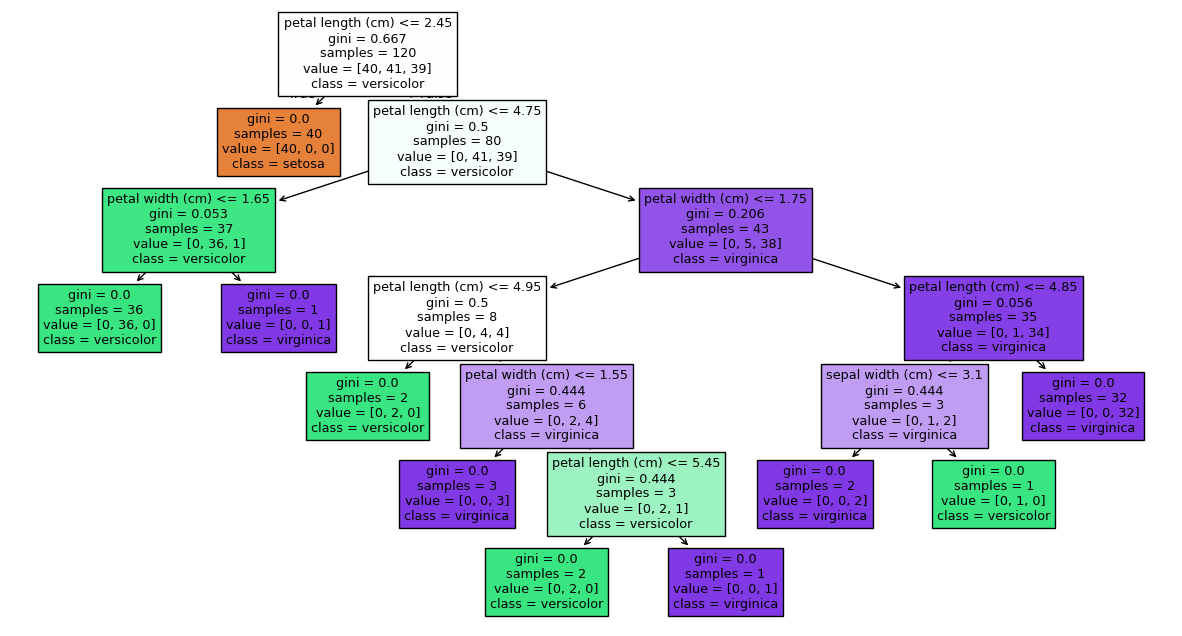

In [9]:
plt.figure(figsize=(15,8))

plot_tree(
    tree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()

In [10]:
tree_small = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_small.fit(X_train, y_train)

pred = tree_small.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 1.0


In [11]:
forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [12]:
forest_pred = forest.predict(X_test)

In [13]:
print("Random Forest Accuracy:")
print(accuracy_score(y_test, forest_pred))

Random Forest Accuracy:
1.0


In [14]:
print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred))

print("Random Forest Accuracy:",
      accuracy_score(y_test, forest_pred))

Decision Tree Accuracy: 1.0
Random Forest Accuracy: 1.0


In [15]:
importance = pd.DataFrame({
    "Feature": iris.feature_names,
    "Importance": forest.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

             Feature  Importance
2  petal length (cm)    0.439994
3   petal width (cm)    0.421522
0  sepal length (cm)    0.108098
1   sepal width (cm)    0.030387


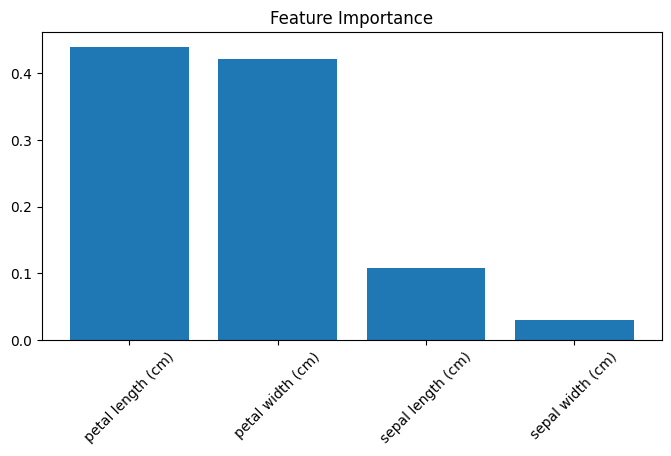

In [16]:
plt.figure(figsize=(8,4))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()